# Leader/follower behavior by named agent

This notebook reads `main_phase(1).csv` and calculates the original leader/follower movement behavior measure for each named partner agent.

Important distinction:

- The bar value is computed from observed movement behavior in the CSV.
- The agent's preset \(\lambda\) is used only for the x-axis label.
- Negative preset \(\lambda\) is labeled as **follower**.
- Positive preset \(\lambda\) is labeled as **leader**.
- Significance tests whether the observed behavior measure differs from balance/chance.

Main behavior measure used for the bar plot:

\[
\text{leader share} = \frac{\#\text{leader moves}}{\#\text{leader moves} + \#\text{follower moves}}
\]

A value above 0.5 means more leader-like movement. A value below 0.5 means more follower-like movement.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
except Exception:
    stats = None

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

INPUT_CSV = Path("main_phase(1).csv")

# Only used for plot labels, NOT used for calculating the behavior bars.
# Fill in the exact preset lambda values from your agent code here.
# Convention for labels in this notebook:
#   negative lambda = follower preset
#   positive lambda = leader preset
AGENT_LAMBDA = {
    "Tom": np.nan,
    "Jerry": np.nan,
    "Cindy": np.nan,
    "Frank": np.nan,
    "Alice": np.nan,
    "Grace": np.nan,
}

# Main plotted behavior metric.
# Keep this as leader_share_lf_only for the original leader / (leader + follower) calculation.
PLOT_METRIC = "leader_share_lf_only"
CHANCE_VALUE = 0.5
ALPHA = 0.05

if not INPUT_CSV.exists():
    candidates = sorted(Path(".").glob("main_phase*.csv"))
    if not candidates:
        raise FileNotFoundError("No main_phase CSV found in this folder.")
    INPUT_CSV = candidates[0]

print("Reading:", INPUT_CSV)
df = pd.read_csv(INPUT_CSV)
print("Rows:", len(df), "Columns:", len(df.columns))
df.head()

Reading: main_phase.csv
Rows: 7461 Columns: 70


,source_file,participant_id,main_row_index,iso_time,iso_time_parsed,phase,event_type,event_name,action_clean,actor_type,role,action,is_role_action,is_human_action,is_agent_action,success_bool,rt_ms,rt_sec,phase_index,key,repetition,round,turn_global,turn_index_in_round,move_index_in_turn,current_x,current_y,from_x,from_y,to_x,to_y,dx,dy,clamped,success,reason,forager_x,forager_y,security_x,security_y,forager_stun_turns,gold_total,gold_delta,tile_gold_mine,tile_mine_type,tile_x,tile_y,depletion_status,chase_status,alien_id,alien_x,alien_y,has_alien,chased_away,found_alien_count,found_alien_id,scan_center_x,scan_center_y,scanned_tile_count,map_name,map_reward_level,map_risk_level,map_num,partner_name,partner_role,human_role,decay_prob,mine_type_key,mine_type_raw,rng_u
0,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,1,2026-05-12T03:37:10.178Z,2026-05-12 03:37:10.178000+00:00,main,phase_event,game_start,game_start,NaN,NaN,NaN,False,False,False,False,6208.0,6.208,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,2,2026-05-12T03:37:12.995Z,2026-05-12 03:37:12.995000+00:00,main,phase_event,game_start,game_start,NaN,NaN,NaN,False,False,False,False,2816.0,2.816,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,3,2026-05-12T03:37:16.268Z,2026-05-12 03:37:16.268000+00:00,main,phase_event,game_start,game_start,NaN,NaN,NaN,False,False,False,False,3274.0,3.274,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,4,2026-05-12T03:37:18.018Z,2026-05-12 03:37:18.018000+00:00,main,phase_event,game_start,game_start,NaN,NaN,NaN,False,False,False,False,1750.0,1.750,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,5,2026-05-12T03:38:52.266Z,2026-05-12 03:38:52.266000+00:00,main,phase_event,game_start,game_start,NaN,NaN,NaN,False,False,False,False,94248.0,94.248,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Classify movement rows

For every movement action, the notebook compares the mover's Manhattan distance to the other role before and after the move.

- distance increases = leader move
- distance decreases = follower move
- distance unchanged = neutral move
- no actual position change = excluded from the main summary


In [2]:
move_actions = {"move_up", "move_down", "move_left", "move_right"}

moves = df[
    df["action_clean"].isin(move_actions)
    & df["event_name"].eq("move")
    & df["partner_name"].notna()
].copy()

needed_cols = [
    "participant_id", "partner_name", "actor_type", "role",
    "from_x", "from_y", "to_x", "to_y",
    "forager_x", "forager_y", "security_x", "security_y",
]
missing = [c for c in needed_cols if c not in moves.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

moves = moves.dropna(subset=needed_cols).copy()

# The moving role is in `role`.
# If forager moved, the other role is security; if security moved, the other role is forager.
moves["other_role"] = np.where(moves["role"].eq("forager"), "security", "forager")
moves["other_x"] = np.where(moves["role"].eq("forager"), moves["security_x"], moves["forager_x"])
moves["other_y"] = np.where(moves["role"].eq("forager"), moves["security_y"], moves["forager_y"])

moves["distance_before"] = (moves["from_x"] - moves["other_x"]).abs() + (moves["from_y"] - moves["other_y"]).abs()
moves["distance_after"] = (moves["to_x"] - moves["other_x"]).abs() + (moves["to_y"] - moves["other_y"]).abs()
moves["distance_change"] = moves["distance_after"] - moves["distance_before"]

moves["changed_position"] = (moves["from_x"].ne(moves["to_x"])) | (moves["from_y"].ne(moves["to_y"]))

moves["movement_label"] = np.select(
    [
        ~moves["changed_position"],
        moves["distance_change"].gt(0),
        moves["distance_change"].lt(0),
        moves["distance_change"].eq(0),
    ],
    ["no_position_change", "leader", "follower", "neutral"],
    default="unknown",
)

print("Classified move rows:", len(moves))
print(moves["movement_label"].value_counts(dropna=False))
moves.head()

Classified move rows: 5204
movement_label
leader                2722
follower              2478
no_position_change       4
Name: count, dtype: int64


,source_file,participant_id,main_row_index,iso_time,iso_time_parsed,phase,event_type,event_name,action_clean,actor_type,role,action,is_role_action,is_human_action,is_agent_action,success_bool,rt_ms,rt_sec,phase_index,key,repetition,round,turn_global,turn_index_in_round,move_index_in_turn,current_x,current_y,from_x,from_y,to_x,to_y,dx,dy,clamped,success,reason,forager_x,forager_y,security_x,security_y,forager_stun_turns,gold_total,gold_delta,tile_gold_mine,tile_mine_type,tile_x,tile_y,depletion_status,chase_status,alien_id,alien_x,alien_y,has_alien,chased_away,found_alien_count,found_alien_id,scan_center_x,scan_center_y,scanned_tile_count,map_name,map_reward_level,map_risk_level,map_num,partner_name,partner_role,human_role,decay_prob,mine_type_key,mine_type_raw,rng_u,other_role,other_x,other_y,distance_before,distance_after,distance_change,changed_position,movement_label
46,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,47,2026-05-12T03:47:39.791Z,2026-05-12 03:47:39.791000+00:00,main,role_action,move,move_left,human,forager,move_left,True,True,False,False,6044.0,6.044,1.0,ArrowLeft,1.0,1.0,NaN,NaN,1.0,5.0,6.0,6.0,6.0,5.0,6.0,-1.0,0.0,0.0,NaN,NaN,6.0,6.0,6.0,6.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low_reward_low_risk_01.csv,low,low,1.0,Alice,security,forager,NaN,NaN,NaN,NaN,security,6.0,6.0,0.0,1.0,1.0,True,leader
47,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,48,2026-05-12T03:47:43.183Z,2026-05-12 03:47:43.183000+00:00,main,role_action,move,move_left,human,forager,move_left,True,True,False,False,3392.0,3.392,1.0,ArrowLeft,1.0,1.0,NaN,NaN,2.0,4.0,6.0,5.0,6.0,4.0,6.0,-1.0,0.0,0.0,NaN,NaN,5.0,6.0,6.0,6.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low_reward_low_risk_01.csv,low,low,1.0,Alice,security,forager,NaN,NaN,NaN,NaN,security,6.0,6.0,1.0,2.0,1.0,True,leader
48,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,49,2026-05-12T03:47:47.798Z,2026-05-12 03:47:47.798000+00:00,main,role_action,move,move_left,human,forager,move_left,True,True,False,False,4615.0,4.615,1.0,ArrowLeft,1.0,1.0,NaN,NaN,3.0,3.0,6.0,4.0,6.0,3.0,6.0,-1.0,0.0,0.0,NaN,NaN,4.0,6.0,6.0,6.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low_reward_low_risk_01.csv,low,low,1.0,Alice,security,forager,NaN,NaN,NaN,NaN,security,6.0,6.0,2.0,3.0,1.0,True,leader
49,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,50,2026-05-12T03:47:48.072Z,2026-05-12 03:47:48.072000+00:00,main,role_action,move,move_left,human,forager,move_left,True,True,False,False,274.0,0.274,1.0,ArrowLeft,1.0,1.0,NaN,NaN,4.0,2.0,6.0,3.0,6.0,2.0,6.0,-1.0,0.0,0.0,NaN,NaN,3.0,6.0,6.0,6.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low_reward_low_risk_01.csv,low,low,1.0,Alice,security,forager,NaN,NaN,NaN,NaN,security,6.0,6.0,3.0,4.0,1.0,True,leader
50,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,51,2026-05-12T03:47:48.534Z,2026-05-12 03:47:48.534000+00:00,main,role_action,move,move_left,human,forager,move_left,True,True,False,False,462.0,0.462,1.0,ArrowLeft,1.0,1.0,NaN,NaN,5.0,1.0,6.0,2.0,6.0,1.0,6.0,-1.0,0.0,0.0,NaN,NaN,2.0,6.0,6.0,6.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low_reward_low_risk_01.csv,low,low,1.0,Alice,security,forager,NaN,NaN,NaN,NaN,security,6.0,6.0,4.0,5.0,1.0,True,leader


## Summarize observed behavior per participant × agent

This part uses only moves made by the named partner agent (`actor_type == "agent"`).

The preset \(\lambda\) values are merged afterward only for labeling.


In [3]:
def summarize_movement(data, group_cols):
    out = (
        data.groupby(group_cols + ["movement_label"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    for col in ["leader", "follower", "neutral", "no_position_change"]:
        if col not in out.columns:
            out[col] = 0

    out = out.rename(columns={
        "leader": "leader_count",
        "follower": "follower_count",
        "neutral": "neutral_count",
        "no_position_change": "no_position_change_count",
    })

    out["valid_move_count"] = out["leader_count"] + out["follower_count"] + out["neutral_count"]
    out["leader_follower_count"] = out["leader_count"] + out["follower_count"]

    out["leader_follower_ratio"] = np.where(
        out["follower_count"].gt(0),
        out["leader_count"] / out["follower_count"],
        np.nan,
    )
    out["leader_share_lf_only"] = np.where(
        out["leader_follower_count"].gt(0),
        out["leader_count"] / out["leader_follower_count"],
        np.nan,
    )
    out["follower_share_lf_only"] = np.where(
        out["leader_follower_count"].gt(0),
        out["follower_count"] / out["leader_follower_count"],
        np.nan,
    )
    out["leader_prop_all_valid_moves"] = np.where(
        out["valid_move_count"].gt(0),
        out["leader_count"] / out["valid_move_count"],
        np.nan,
    )
    out["follower_prop_all_valid_moves"] = np.where(
        out["valid_move_count"].gt(0),
        out["follower_count"] / out["valid_move_count"],
        np.nan,
    )
    out["neutral_prop_all_valid_moves"] = np.where(
        out["valid_move_count"].gt(0),
        out["neutral_count"] / out["valid_move_count"],
        np.nan,
    )

    return out.sort_values(group_cols).reset_index(drop=True)

valid_moves = moves[moves["movement_label"].ne("no_position_change")].copy()
agent_moves = valid_moves[valid_moves["actor_type"].eq("agent")].copy()

agent_by_participant = summarize_movement(agent_moves, ["participant_id", "partner_name", "role"])
agent_by_participant = agent_by_participant.rename(columns={"role": "agent_role"})
agent_by_participant["preset_lambda"] = agent_by_participant["partner_name"].map(AGENT_LAMBDA)
agent_by_participant["preset_lambda_direction"] = np.select(
    [
        agent_by_participant["preset_lambda"].lt(0),
        agent_by_participant["preset_lambda"].gt(0),
        agent_by_participant["preset_lambda"].eq(0),
    ],
    ["follower", "leader", "neutral"],
    default="unknown",
)

print("Participant × agent behavior summary:")
display(agent_by_participant)


Participant × agent behavior summary:


movement_label,participant_id,partner_name,agent_role,follower_count,leader_count,neutral_count,no_position_change_count,valid_move_count,leader_follower_count,leader_follower_ratio,leader_share_lf_only,follower_share_lf_only,leader_prop_all_valid_moves,follower_prop_all_valid_moves,neutral_prop_all_valid_moves,preset_lambda,preset_lambda_direction
0,Bill,Alice,security,48,86,0,0,134,134,1.791667,0.641791,0.358209,0.641791,0.358209,0.0,NaN,unknown
1,Bill,Cindy,security,89,44,0,0,133,133,0.494382,0.330827,0.669173,0.330827,0.669173,0.0,NaN,unknown
2,Bill,Frank,forager,1,92,0,0,93,93,92.000000,0.989247,0.010753,0.989247,0.010753,0.0,NaN,unknown
3,Bill,Grace,forager,94,16,0,0,110,110,0.170213,0.145455,0.854545,0.145455,0.854545,0.0,NaN,unknown
4,Bill,Jerry,forager,25,61,0,0,86,86,2.440000,0.709302,0.290698,0.709302,0.290698,0.0,NaN,unknown
5,Bill,Tom,security,53,77,0,0,130,130,1.452830,0.592308,0.407692,0.592308,0.407692,0.0,NaN,unknown
6,Cici Zhang,Alice,security,53,86,0,0,139,139,1.622642,0.618705,0.381295,0.618705,0.381295,0.0,NaN,unknown
7,Cici Zhang,Cindy,security,87,52,0,0,139,139,0.597701,0.374101,0.625899,0.374101,0.625899,0.0,NaN,unknown
8,Cici Zhang,Frank,forager,21,63,0,0,84,84,3.000000,0.750000,0.250000,0.750000,0.250000,0.0,NaN,unknown
9,Cici Zhang,Grace,forager,84,46,0,0,130,130,0.547619,0.353846,0.646154,0.353846,0.646154,0.0,NaN,unknown


## Average across participants and test significance

For each agent, the notebook calculates the participant-average behavior bar and tests whether the participant-level behavior measure differs from balance.

For the default behavior metric, the null value is 0.5.


In [4]:
def sem(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 2:
        return np.nan
    return x.std(ddof=1) / np.sqrt(len(x))

def one_sample_ttest(x, null_value=0.5):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    mean = x.mean() if n else np.nan
    s = x.std(ddof=1) if n > 1 else np.nan
    se = s / np.sqrt(n) if n > 1 else np.nan

    if n < 2 or pd.isna(se) or se == 0:
        return pd.Series({"n": n, "mean": mean, "sem": se, "t": np.nan, "p": np.nan})

    if stats is not None:
        t, p = stats.ttest_1samp(x, popmean=null_value, nan_policy="omit")
    else:
        # Fallback: gives t but not an exact p-value if scipy is unavailable.
        t = (mean - null_value) / se
        p = np.nan

    return pd.Series({"n": n, "mean": mean, "sem": se, "t": t, "p": p})

def stars_from_p(p):
    if pd.isna(p):
        return "n/a"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."

def label_for_agent(name):
    lam = AGENT_LAMBDA.get(name, np.nan)
    if pd.isna(lam):
        return f"{name}\nλ=?"
    direction = "follower" if lam < 0 else "leader" if lam > 0 else "neutral"
    return f"{name}\nλ={lam:+.2f}\n{direction}"

agent_stats = (
    agent_by_participant
    .groupby("partner_name")[PLOT_METRIC]
    .apply(lambda x: one_sample_ttest(x, CHANCE_VALUE))
    .reset_index()
    .pivot(index="partner_name", columns="level_1", values=PLOT_METRIC)
    .reset_index()
)

# Add totals from the raw counts for context.
totals = (
    agent_by_participant
    .groupby("partner_name")
    .agg(
        total_leader_count=("leader_count", "sum"),
        total_follower_count=("follower_count", "sum"),
        total_neutral_count=("neutral_count", "sum"),
        total_valid_move_count=("valid_move_count", "sum"),
        total_leader_follower_count=("leader_follower_count", "sum"),
    )
    .reset_index()
)

tag = pd.DataFrame({
    "partner_name": list(AGENT_LAMBDA.keys()),
    "preset_lambda": list(AGENT_LAMBDA.values()),
})
tag["preset_lambda_direction"] = np.select(
    [tag["preset_lambda"].lt(0), tag["preset_lambda"].gt(0), tag["preset_lambda"].eq(0)],
    ["follower", "leader", "neutral"],
    default="unknown",
)

agent_stats = agent_stats.merge(totals, on="partner_name", how="left").merge(tag, on="partner_name", how="left")
agent_stats["significance"] = agent_stats["p"].map(stars_from_p)
agent_stats["plot_label"] = agent_stats["partner_name"].map(label_for_agent)

# Sort by preset lambda if available; otherwise sort by observed mean.
if agent_stats["preset_lambda"].notna().any():
    agent_stats = agent_stats.sort_values("preset_lambda", na_position="last").reset_index(drop=True)
else:
    agent_stats = agent_stats.sort_values("mean").reset_index(drop=True)

print("Agent-level average and significance:")
display(agent_stats[[
    "partner_name", "preset_lambda", "preset_lambda_direction", "n", "mean", "sem", "t", "p", "significance",
    "total_leader_count", "total_follower_count", "total_neutral_count", "total_valid_move_count"
]])


Agent-level average and significance:


,partner_name,preset_lambda,preset_lambda_direction,n,mean,sem,t,p,significance,total_leader_count,total_follower_count,total_neutral_count,total_valid_move_count
0,Grace,NaN,unknown,4.0,0.288035,0.048484,-4.371891,0.022139,*,129,317,0,446
1,Cindy,NaN,unknown,4.0,0.379117,0.017990,-6.719496,0.006728,**,206,337,0,543
2,Tom,NaN,unknown,4.0,0.585046,0.021858,3.890818,0.030105,*,311,221,0,532
3,Alice,NaN,unknown,4.0,0.657795,0.023837,6.619854,0.007020,**,359,186,0,545
4,Jerry,NaN,unknown,4.0,0.759437,0.021281,12.190900,0.001188,**,290,90,0,380
5,Frank,NaN,unknown,4.0,0.880890,0.049430,7.705687,0.004543,**,337,44,0,381


## Bar plot: observed leader/follower behavior

The bars are observed participant-averaged behavior. The \(\lambda\) value in the label is only the agent's preset label.


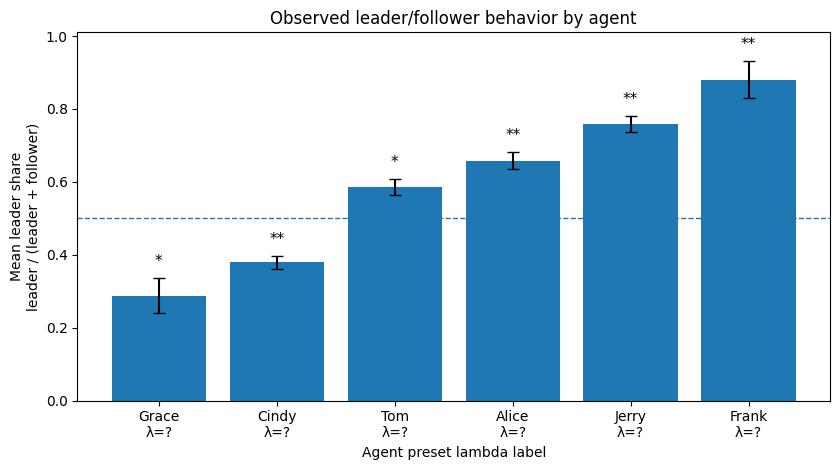

In [5]:
plot_df = agent_stats.copy()

x = np.arange(len(plot_df))
y = plot_df["mean"].astype(float).to_numpy()
yerr = plot_df["sem"].astype(float).to_numpy()

plt.figure(figsize=(8.5, 4.8))
plt.bar(x, y, yerr=yerr, capsize=4)
plt.axhline(CHANCE_VALUE, linestyle="--", linewidth=1)
plt.xticks(x, plot_df["plot_label"], rotation=0)
plt.ylabel("Mean leader share\nleader / (leader + follower)")
plt.xlabel("Agent preset lambda label")
plt.title("Observed leader/follower behavior by agent")
plt.ylim(0, max(1.0, np.nanmax(y + np.nan_to_num(yerr, nan=0)) + 0.08))

for xi, yi, se, sig in zip(x, y, yerr, plot_df["significance"]):
    offset = 0.025 if pd.isna(se) else se + 0.025
    plt.text(xi, yi + offset, sig, ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()


## Separate significance plot

This plot shows the statistical evidence for each agent's observed behavior differing from balance.

The dotted line is \(p = 0.05\). Values above the line are significant at the default threshold.


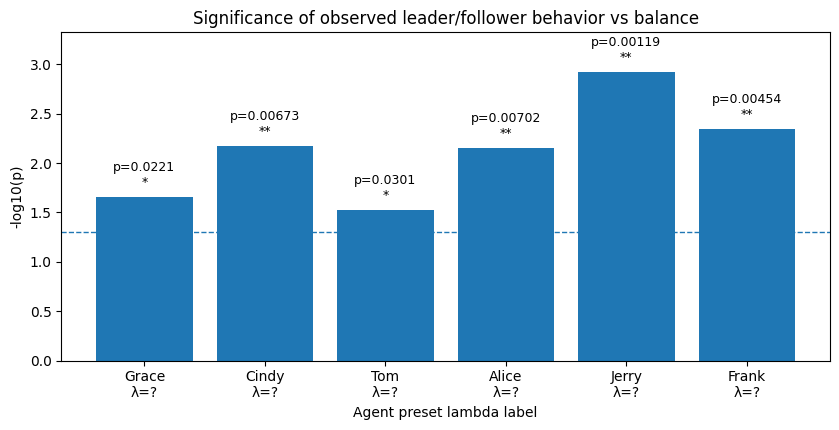

,partner_name,preset_lambda,mean,t,p,significance
0,Grace,NaN,0.288035,-4.371891,0.022139,*
1,Cindy,NaN,0.379117,-6.719496,0.006728,**
2,Tom,NaN,0.585046,3.890818,0.030105,*
3,Alice,NaN,0.657795,6.619854,0.007020,**
4,Jerry,NaN,0.759437,12.190900,0.001188,**
5,Frank,NaN,0.880890,7.705687,0.004543,**


In [6]:
sig_df = agent_stats.copy()
sig_df["neg_log10_p"] = -np.log10(sig_df["p"].astype(float))
threshold = -np.log10(ALPHA)

x = np.arange(len(sig_df))
y = sig_df["neg_log10_p"].to_numpy()

plt.figure(figsize=(8.5, 4.4))
plt.bar(x, y)
plt.axhline(threshold, linestyle="--", linewidth=1)
plt.xticks(x, sig_df["plot_label"], rotation=0)
plt.ylabel("-log10(p)")
plt.xlabel("Agent preset lambda label")
plt.title("Significance of observed leader/follower behavior vs balance")

finite_y = y[np.isfinite(y)]
ymax = max(threshold + 0.5, finite_y.max() + 0.4 if len(finite_y) else threshold + 0.5)
plt.ylim(0, ymax)

for xi, yi, p, sig in zip(x, y, sig_df["p"], sig_df["significance"]):
    if pd.isna(p):
        label = "p=n/a"
        ypos = threshold * 0.2
    else:
        label = f"p={p:.3g}\n{sig}"
        ypos = yi + 0.08
    plt.text(xi, ypos, label, ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

display(sig_df[["partner_name", "preset_lambda", "mean", "t", "p", "significance"]])


## Optional: participant-level plot

This plot shows each participant's behavior value for each agent, with the agent mean overlaid.


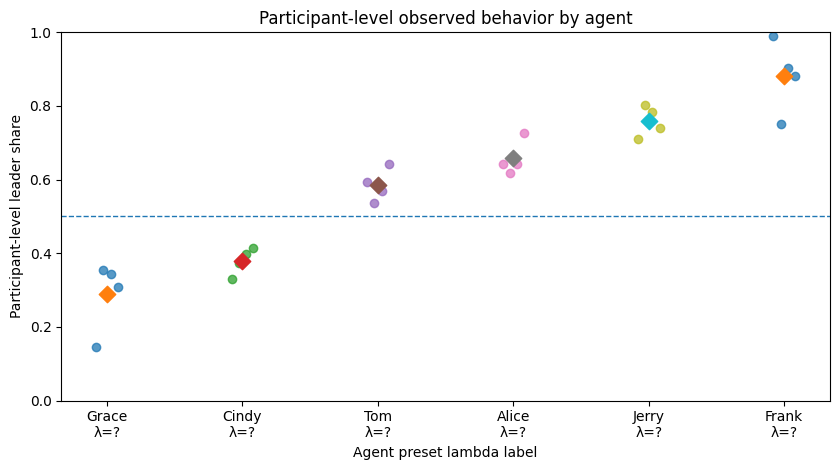

In [7]:
plot_points = agent_by_participant.merge(agent_stats[["partner_name", "plot_label"]], on="partner_name", how="left")
order = agent_stats["partner_name"].tolist()
label_map = dict(zip(agent_stats["partner_name"], agent_stats["plot_label"]))

plt.figure(figsize=(8.5, 4.8))
for xi, name in enumerate(order):
    vals = plot_points.loc[plot_points["partner_name"].eq(name), PLOT_METRIC].dropna().astype(float).to_numpy()
    if len(vals):
        jitter = np.linspace(-0.08, 0.08, len(vals)) if len(vals) > 1 else np.array([0.0])
        plt.scatter(np.full(len(vals), xi) + jitter, vals, alpha=0.75)
        plt.scatter([xi], [agent_stats.loc[agent_stats["partner_name"].eq(name), "mean"].iloc[0]], marker="D", s=70)

plt.axhline(CHANCE_VALUE, linestyle="--", linewidth=1)
plt.xticks(np.arange(len(order)), [label_map[n] for n in order], rotation=0)
plt.ylabel("Participant-level leader share")
plt.xlabel("Agent preset lambda label")
plt.title("Participant-level observed behavior by agent")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
